In [284]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kstest # for Kolmogorov-Smirnov test
from scipy.stats import f_oneway # for ANOVA test
from scipy.stats import chi2_contingency # for Chi-square test
import itertools # for combinations 
import plotly.graph_objects as go

In [285]:
# load dataset unified
df = pd.read_csv('../data/ech_annonces_unified_68.csv',sep=';')

In [286]:
df.head(5)

,idannonce,type_annonceur,typedebien,typedetransaction,etage,surface,surface_terrain,nb_pieces,prix_bien,prix_maison,...,REG,DEP,type_transaction,loyer_m2_median_n6,nb_log_n6,taux_rendement_n6,loyer_m2_median_n7,nb_log_n7,taux_rendement_n7,prix_m2_vente
0,immo-facile-52417007,pr,m,l,0,116,NaN,5,1250,NaN,...,44,68,location,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ag672097-382986683,pr,a,l,3,44,NaN,3,600,NaN,...,44,68,location,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ag672097-383464082,pr,a,l,1,53,NaN,2,498,NaN,...,44,68,location,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ag680864-383044166,pr,a,l,0,41,NaN,2,460,NaN,...,44,68,location,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ag672097-380998252,pr,a,l,2,74,NaN,4,695,NaN,...,44,68,location,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [287]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39439 entries, 0 to 39438
Data columns (total 60 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   idannonce                39439 non-null  object 
 1   type_annonceur           39439 non-null  object 
 2   typedebien               39439 non-null  object 
 3   typedetransaction        39439 non-null  object 
 4   etage                    39439 non-null  int64  
 5   surface                  39439 non-null  int64  
 6   surface_terrain          11951 non-null  float64
 7   nb_pieces                39439 non-null  int64  
 8   prix_bien                39439 non-null  int64  
 9   prix_maison              437 non-null    float64
 10  prix_terrain             437 non-null    float64
 11  mensualiteFinance        39439 non-null  int64  
 12  balcon                   39439 non-null  int64  
 13  eau                      39439 non-null  int64  
 14  bain                  

In [288]:
df.shape

(39439, 60)

In [289]:
# Percentage of missing values per column
df.isna().mean()*100

idannonce                   0.000000
type_annonceur              0.000000
typedebien                  0.000000
typedetransaction           0.000000
etage                       0.000000
surface                     0.000000
surface_terrain            69.697508
nb_pieces                   0.000000
prix_bien                   0.000000
prix_maison                98.891960
prix_terrain               98.891960
mensualiteFinance           0.000000
balcon                      0.000000
eau                         0.000000
bain                        0.000000
dpeL                        0.000000
dpeC                       34.113441
mapCoordonneesLatitude      0.000000
mapCoordonneesLongitude     0.000000
annonce_exclusive           0.000000
nb_etages                  45.510789
parking                    99.931540
places_parking             63.865717
cave                       53.741221
exposition                  0.000000
ges_class                  26.113745
annee_construction         70.250260
n

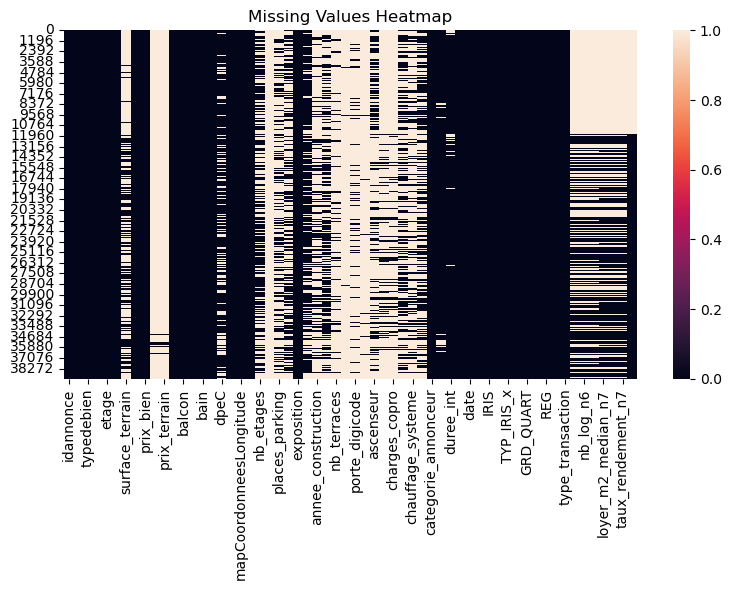

In [290]:
# Visualize missing values heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.isnull(), cbar=True)
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

In [291]:
# Columns with more than 40% missing values

df = df.drop(columns=df.columns[df.isna().mean() > 0.4])

In [292]:
df.shape

(39439, 35)

In [293]:
# Display the sum of duplicated 
df.duplicated().sum()

0

In [294]:
df['type_annonceur'].value_counts()

type_annonceur
pr    39332
pa      107
Name: count, dtype: int64

In [295]:
df['typedebien'].value_counts()

typedebien
a     23835
m     14309
mn      650
an      640
l         5
Name: count, dtype: int64

In [296]:
df.isna().mean()*100

idannonce                   0.000000
type_annonceur              0.000000
typedebien                  0.000000
typedetransaction           0.000000
etage                       0.000000
surface                     0.000000
nb_pieces                   0.000000
prix_bien                   0.000000
mensualiteFinance           0.000000
balcon                      0.000000
eau                         0.000000
bain                        0.000000
dpeL                        0.000000
dpeC                       34.113441
mapCoordonneesLatitude      0.000000
mapCoordonneesLongitude     0.000000
annonce_exclusive           0.000000
exposition                  0.000000
ges_class                  26.113745
categorie_annonceur         0.000000
logement_neuf               2.791653
duree_int                   4.551332
typedebien_lite             0.000000
date                        0.000000
INSEE_COM                   0.000000
IRIS                        0.000000
CODE_IRIS                   0.000000
T

In [297]:
df["duree_int"].dtype

dtype('float64')

In [298]:
df["duree_int"].value_counts()

duree_int
 8.0      2216
-757.0    1836
 15.0     1437
 22.0     1186
 7.0      1075
          ... 
 355.0       1
 502.0       1
 440.0       1
 333.0       1
 606.0       1
Name: count, Length: 522, dtype: int64

In [299]:
df["duree_int"] = df["duree_int"].fillna(df['dpeC'].mean())

In [300]:
# uni
df['logement_neuf'].value_counts()

logement_neuf
n    34730
o     3608
Name: count, dtype: int64

In [301]:
df['logement_neuf'] = df['logement_neuf'].fillna('o')

In [302]:
df['logement_neuf'].value_counts()

logement_neuf
n    34730
o     4709
Name: count, dtype: int64

In [303]:
df['dpeC']

0        226.0
1        220.0
2        272.0
3          NaN
4        206.0
         ...  
39434      NaN
39435      NaN
39436      NaN
39437      NaN
39438      NaN
Name: dpeC, Length: 39439, dtype: float64

In [304]:
df['dpeC'].value_counts

<bound method IndexOpsMixin.value_counts of 0        226.0
1        220.0
2        272.0
3          NaN
4        206.0
         ...  
39434      NaN
39435      NaN
39436      NaN
39437      NaN
39438      NaN
Name: dpeC, Length: 39439, dtype: float64>

In [305]:
df['dpeC'] = df['dpeC'].astype('float64')

In [306]:
df['dpeL'].value_counts()

dpeL
D     8905
E     6101
C     5944
0     5905
NS    2885
VI    2840
B     2563
F     2046
A     1587
G      663
Name: count, dtype: int64

In [307]:
df['dpeC'] = df['dpeC'].fillna(df['dpeC'].mean())

In [308]:
df['ges_class'].isna().mean()*100

26.113745277517182

In [309]:
df['ges_class'].dtype

dtype('O')

In [310]:
# 
df['ges_class'].value_counts

<bound method IndexOpsMixin.value_counts of 0          B
1          B
2          E
3        NaN
4          D
        ... 
39434    NaN
39435    NaN
39436    NaN
39437    NaN
39438    NaN
Name: ges_class, Length: 39439, dtype: object>

In [311]:
df['ges_class'] = df['ges_class'].fillna('mode')

In [312]:
# 
df = df.drop(['idannonce','date'], axis=1)

# Data Quality

## Investigate the target variable 'prix_m2_vente'


In [313]:
# investigate the target variable 'prix_m2_vente'
df_investigate = df[['typedebien' , 'prix_bien'  , 'surface','prix_m2_vente']]
df_investigate.dropna()


,typedebien,prix_bien,surface,prix_m2_vente
11702,a,128400,64,2006.25
11703,m,189000,85,2223.53
11704,m,282900,187,1512.83
11705,a,79000,76,1039.47
11706,m,317000,90,3522.22
...,...,...,...,...
39434,an,122000,26,4692.31
39435,an,202900,83,2444.58
39436,an,218400,90,2426.67
39437,an,222900,89,2504.49


In [314]:
# display the dataset with unique values of 'typedebien'
for typedebien in df_investigate['typedebien'].unique():
    print(f"\n{'='*50}")
    print(f"Type de Bien: {typedebien}")
    print(f"{'='*50}")
    display(df_investigate[df_investigate['typedebien'] == typedebien].head(10))
    print(f"Count: {len(df_investigate[df_investigate['typedebien'] == typedebien])}")



Type de Bien: m


,typedebien,prix_bien,surface,prix_m2_vente
0,m,1250,116,NaN
32,m,1030,100,NaN
70,m,1130,120,NaN
76,m,1950,146,NaN
77,m,750,65,NaN
92,m,2400,121,NaN
93,m,1400,85,NaN
100,m,1800,165,NaN
120,m,1080,110,NaN
155,m,1500,187,NaN


Count: 14309

Type de Bien: a


,typedebien,prix_bien,surface,prix_m2_vente
1,a,600,44,NaN
2,a,498,53,NaN
3,a,460,41,NaN
4,a,695,74,NaN
5,a,900,102,NaN
6,a,700,70,NaN
7,a,680,68,NaN
8,a,755,65,NaN
9,a,995,84,NaN
10,a,500,50,NaN


Count: 23835

Type de Bien: l


...

Count: 5

Type de Bien: an


,typedebien,prix_bien,surface,prix_m2_vente
11887,an,396500,66,6007.58
11918,an,253000,85,2976.47
12747,an,258000,70,3685.71
12857,an,261900,66,3968.18
12891,an,244000,69,3536.23
12939,an,238000,68,3500.00
12982,an,190000,69,2753.62
12998,an,256500,88,2914.77
13213,an,267150,86,3106.40
13294,an,247250,86,2875.00


Count: 640

Type de Bien: mn


,typedebien,prix_bien,surface,prix_m2_vente
34253,mn,262100,100,2621.00
34254,mn,275100,98,2807.14
34255,mn,378784,133,2848.00
34256,mn,289568,95,3048.08
34257,mn,343428,103,3334.25
34259,mn,352932,100,3529.32
34260,mn,422932,125,3383.46
34266,mn,227250,98,2318.88
34269,mn,316800,110,2880.00
34275,mn,420000,120,3500.00


Count: 650


In [315]:
df['prix_m2_vente'].isna().mean()*100

29.671137706331297

In [316]:
# Conclusion: The target variable 'prix_m2_vente' we can calculate based on the 'prix_bien' and 'surface' 
# More we can fill missing values in 'prix_m2_vente' using this calculation

df['prix_m2_vente'] = df['prix_bien'] / df['surface']

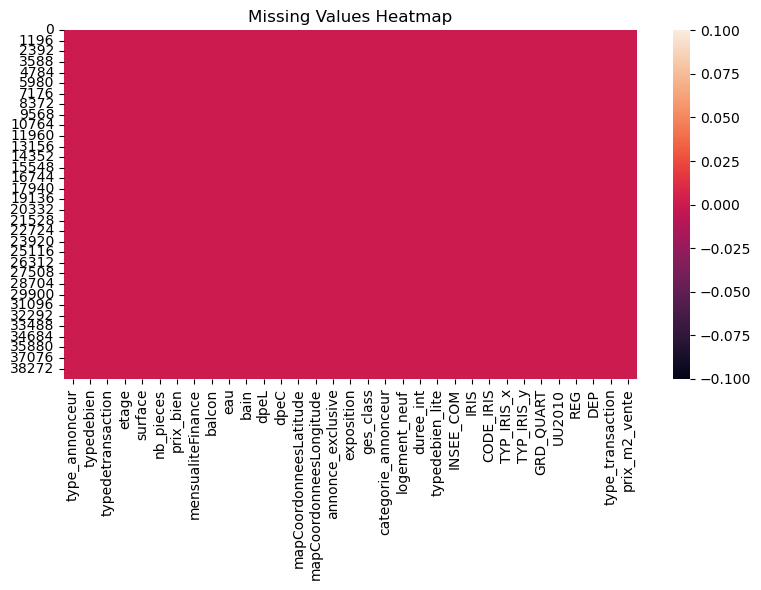

In [317]:
# Visualize missing values heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.isnull(), cbar=True)
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

In [318]:
df.isna().mean()*100

type_annonceur             0.0
typedebien                 0.0
typedetransaction          0.0
etage                      0.0
surface                    0.0
nb_pieces                  0.0
prix_bien                  0.0
mensualiteFinance          0.0
balcon                     0.0
eau                        0.0
bain                       0.0
dpeL                       0.0
dpeC                       0.0
mapCoordonneesLatitude     0.0
mapCoordonneesLongitude    0.0
annonce_exclusive          0.0
exposition                 0.0
ges_class                  0.0
categorie_annonceur        0.0
logement_neuf              0.0
duree_int                  0.0
typedebien_lite            0.0
INSEE_COM                  0.0
IRIS                       0.0
CODE_IRIS                  0.0
TYP_IRIS_x                 0.0
TYP_IRIS_y                 0.0
GRD_QUART                  0.0
UU2010                     0.0
REG                        0.0
DEP                        0.0
type_transaction           0.0
prix_m2_

In [319]:
df['annonce_exclusive'].value_counts()

annonce_exclusive
0      15993
Oui    11818
Non    11628
Name: count, dtype: int64

In [320]:
# Select numerical variables
var_num = df.select_dtypes(include=['int', 'float'])
# Select categorical variables
var_cat = df.select_dtypes(include=['object','category'])

In [321]:
var_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39439 entries, 0 to 39438
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   etage                    39439 non-null  int64  
 1   surface                  39439 non-null  int64  
 2   nb_pieces                39439 non-null  int64  
 3   prix_bien                39439 non-null  int64  
 4   mensualiteFinance        39439 non-null  int64  
 5   balcon                   39439 non-null  int64  
 6   eau                      39439 non-null  int64  
 7   bain                     39439 non-null  int64  
 8   dpeC                     39439 non-null  float64
 9   mapCoordonneesLatitude   39439 non-null  float64
 10  mapCoordonneesLongitude  39439 non-null  float64
 11  duree_int                39439 non-null  float64
 12  INSEE_COM                39439 non-null  int64  
 13  IRIS                     39439 non-null  int64  
 14  CODE_IRIS             

In [322]:
var_cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39439 entries, 0 to 39438
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   type_annonceur       39439 non-null  object
 1   typedebien           39439 non-null  object
 2   typedetransaction    39439 non-null  object
 3   dpeL                 39439 non-null  object
 4   annonce_exclusive    39439 non-null  object
 5   exposition           39439 non-null  object
 6   ges_class            39439 non-null  object
 7   categorie_annonceur  39439 non-null  object
 8   logement_neuf        39439 non-null  object
 9   typedebien_lite      39439 non-null  object
 10  TYP_IRIS_x           39439 non-null  object
 11  TYP_IRIS_y           39439 non-null  object
 12  type_transaction     39439 non-null  object
dtypes: object(13)
memory usage: 3.9+ MB


In [323]:
var_cat

,type_annonceur,typedebien,typedetransaction,dpeL,annonce_exclusive,exposition,ges_class,categorie_annonceur,logement_neuf,typedebien_lite,TYP_IRIS_x,TYP_IRIS_y,type_transaction
0,pr,m,l,D,0,0,B,a,n,m,Z,Z,location
1,pr,a,l,D,0,0,B,a,n,a,H,H,location
2,pr,a,l,E,0,0,E,a,n,a,H,H,location
3,pr,a,l,VI,0,0,mode,a,n,a,H,H,location
4,pr,a,l,D,0,0,D,a,n,a,H,H,location
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39434,pr,an,v,0,0,0,mode,ca,o,a,H,H,vente
39435,pr,an,v,0,0,0,mode,ca,o,a,Z,Z,vente
39436,pr,an,v,0,0,0,mode,ca,o,a,Z,Z,vente
39437,pr,an,v,0,0,0,mode,ca,o,a,Z,Z,vente


In [324]:
df.to_csv('../data/df_cleaned.csv',sep=';')